# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# Filtros Adaptativos e Equalização de Canais

Filtros adaptativos são sistemas capazes de ajustar seus coeficientes automaticamente para minimizar um erro, adaptando-se a ambientes desconhecidos ou variantes no tempo. Diferente dos filtros fixos, eles operam em malha fechada, utilizando o erro entre a saída e um sinal desejado para atualizar seus pesos.



## Principais Algoritmos

* **LMS (Least Mean Squares):** O mais utilizado devido à sua simplicidade e baixo custo computacional. Baseia-se no gradiente estocástico para minimizar o erro quadrático médio.
    * **Equação de atualização:** $$\mathbf{w}(n+1) = \mathbf{w}(n) + \mu e(n) \mathbf{x}(n)$$
* **CMA (Constant Modulus Algorithm):** Essencial para **equalização cega** (sem sinal de referência), buscando restaurar o módulo constante de sinais modulados.
* **Outros (RLS, NLMS):** O **RLS** oferece convergência rápida com maior custo computacional, enquanto o **NLMS** normaliza o passo de adaptação para maior estabilidade.



## Livro-Texto Base

> **Adaptive Filtering: Algorithms and Practical Implementation (5ed)**
> *Paulo S. R. Diniz* 

Caps. 1, 2, 3 e 13

## Objetivos da Capacitação 

1.  **Implementação:** Codificar o algoritmo **LMS**.
2.  **Aplicação:** Realizar a **equalização de um canal passa-baixas**, visando mitigar a Interferência Intersimbólica (ISI).
3.  **Avaliação de Desempenho:**
    * Utilizar o **MSE (Mean Squared Error)** como métrica de convergência.
    * Analisar o impacto do **passo de adaptação ($\mu$)** (velocidade vs. erro residual).
    * Testar a robustez do sistema sob diferentes condições de **SNR**.



# O Algoritmo LMS (Least Mean Squares)

O diagrama de blocos acima ilustra a estrutura padrão de um filtro adaptativo. O algoritmo **LMS** atua dentro do bloco "Adaptive Algorithm", ajustando os coeficientes do filtro linear para minimizar o erro entre a saída do filtro e um sinal desejado.

![Texto Alternativo](images/lmsbasic.png)


Abaixo, descrevemos o funcionamento passo a passo com base nas variáveis ilustradas:

### 1. Definição das Variáveis

Com base no diagrama e na literatura do curso:

* $\mathbf{x}[k]$ : **Vetor de Entrada**. Contém a amostra atual e as amostras passadas do sinal de entrada (linha de atraso).
* $\mathbf{h}[k]$: **Vetor de Coeficientes**. Representa os pesos do filtro linear (FIR) no instante . O objetivo do LMS é encontrar os valores ótimos para este vetor.
* $\mathbf{y}[k]$: **Saída do Filtro**. É a estimativa do sinal desejado, calculada pela convolução (ou produto interno) entre a entrada e os coeficientes atuais.
* $\mathbf{d}[k]$: **Sinal Desejado** (ou Referência). É o sinal que o sistema tenta reproduzir ou identificar.
*$\mathbf{e}[k]$ : **Sinal de Erro**.  A diferença instantânea entre o que se deseja ($d[k]$) e o que o filtro entregou ($y[k]$).
### 2. O Ciclo de Funcionamento

O algoritmo opera em um ciclo contínuo de realimentação (feedback loop) composto por três etapas principais a cada iteração :

#### Passo 1: Filtragem (Cálculo da Saída)

O filtro linear processa o sinal de entrada $\mathbf{x}[k]$ com os coeficientes atuais $\mathbf{h}[k]$ para gerar a saída estimada:

$$y[k] = \mathbf{h}^T[k] \mathbf{x}[k]$$

#### Passo 2: Cálculo do Erro

O sistema compara a saída estimada $y[k]$ com o sinal desejado $d[k]$ através do somador (subtrator) mostrado no diagrama. Este erro guiará a adaptação:

$$e[k] = d[k] - y[k]$$


#### Passo 3: Atualização dos Pesos (Adaptive Algorithm)

Aqui entra o LMS. Ele utiliza o erro $e[k]$ para atualizar o vetor $\mathbf{h}[k]$, movendo-o na direção oposta ao gradiente do erro quadrático instantâneo. A equação de atualização é:

$$\mathbf{h}[k+1] = \mathbf{h}[k] + 2\mu e[k] \mathbf{x}[k]$$

Onde:

* :Onde:$\mathbf{h}[k+1]$: Novos coeficientes para a próxima iteração.
* $\mu$: Passo de adaptação (step-size). Controla a velocidade de convergência e a estabilidade do filtro.

### 3. Resumo do Algoritmo

O "segredo" do LMS é sua simplicidade computacional. Ao contrário do algoritmo de Wiener, que exige cálculos complexos de matrizes de correlação, o LMS usa o próprio erro instantâneo como uma estimativa estocástica do gradiente.

Para implementar em código, o laço de repetição segue esta lógica:

* 1- Recebe nova amostra $x[k]$ e $d[k]$.
* 2- Calcula $y[k]$.
* 3- Calcula $e[k]$.
* 4- Atualiza $\mathbf{h} \leftarrow \mathbf{h} + \mu e[k] \mathbf{x}[k]$.



### Bibliotecas Importadas

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
from scipy import signal
from numba import njit
from scipy.linalg import toeplitz, inv
import pandas as pd
import numpy as np
import time


In [4]:
@njit
def lms(x, d, Ntaps, mu):
    """
    Implementação do LMS alinhada com o diagrama de blocos fornecido.
    
    Mapeamento Diagrama -> Código:
    - Received Signal x[k]    -> x
    - Desired Signal d[k]     -> d
    - Equalized Output y[k]   -> y
    - Adaptive Filter w[k]    -> w
    - Error Signal e[k]       -> e
    """
    N = len(x)
    
    # 1. Alocação de Memória
    # 'w' representa o vetor de pesos do filtro (Adaptive Filter w[k])
    w = np.zeros(Ntaps) 
    
    # Matriz para salvar o histórico de w[k] ao longo do tempo
    W = np.zeros((N - Ntaps, Ntaps))
    
    squared_e = np.zeros(N)
    y = np.zeros(N) # Equalized Output y[k]
    
    # 2. Inicialização do Buffer
    # Buffer representa o vetor x[k] dentro da linha de atraso do filtro
    buffer = x[0:Ntaps][::-1].copy()
    
    # 3. Loop Principal (Iteração k)
    # k representa o índice de tempo discreto, conforme diagrama
    for k in range(Ntaps, N):
        
        # Atualização do vetor de entrada (regressor)
        buffer[1:] = buffer[:-1]
        buffer[0] = x[k] # Entrada x[k] atual

        # A. Filtragem: y[k] = w[k]^T * x[k]
        # Gera a "Equalized Output"
        y[k] = np.dot(w, buffer)

        # B. Cálculo do Erro: e[k] = d[k] - y[k]
        # Nó de soma no canto inferior direito do diagrama
        e = d[k] - y[k]

        # C. Atualização dos Pesos (LMS Algorithm)
        # Seta "Weight Update" subindo para o filtro
        w += mu * e * buffer 

        # D. Armazenamento
        squared_e[k] = e**2
        
        # Salva o histórico dos pesos W
        W[k - Ntaps, :] = w

    return y, w, squared_e, W


# Objetivo: Equalização de Canal com Algoritmo LMS

Implementar e avaliar o desempenho do algoritmo **LMS (Least Mean Squares)** aplicado à equalização de um canal de comunicação.

![Texto Alternativo](images/equalilms.png)

### Estrutura do Sistema de Equalização

Baseado no diagrama acima, as variáveis do sistema são definidas como:
* $s[k]$ (Transmitted Signal): O sinal de informação original.
* Canal $H(z)$: Modela o meio de transmissão. Neste estudo, utilizamos um modelo passa-baixas
* $v[k]$ (Noise): Ruído aditivo (AWGN) somado ao sinal, simulando interferências térmicas ou do ambiente. O nível deste ruído define a SNR (Signal-to-Noise Ratio).
* $x[k]$ (Received Signal): O sinal distorcido e ruidoso que chega ao receptor. É a entrada do filtro adaptativo, dada por: $$x[k] = s[k] * h[k] + v[k]$$

* Delay $[\Delta]$. : Um atraso proposital aplicado ao sinal desejado. Como o canal físico é causal, o equalizador precisa de um tempo de processamento para estimar o inverso do canal. Portanto, comparamos a saída do equalizador com uma versão atrasada do sinal original ($s[k-\Delta]$).
* $d[k]$(Desired Signal): O sinal de referência para o treino do algoritmo, onde $d[k] = s[k-\Delta]$.
* $y[k]$ (Equalized Output): A tentativa do equalizador de reconstruir $d[k]$.


### Metodologia de Avaliação

O desempenho do equalizador será analisado através da curva de aprendizado e do erro em regime permanente, variando as seguintes condições:

1. **Passo de Adaptação ($\mu$):** Avaliaremos como diferentes valores de  influenciam a velocidade de convergência e a estabilidade do filtro. Espera-se um *trade-off*:  grande converge rápido mas com maior ruído residual (misadjustment);  pequeno é mais estável mas lento.
2. **Relação Sinal-Ruído (SNR):** Testaremos o sistema sob diferentes potências de ruído $v[k]$ . Isso determinará o "piso" de erro mínimo que o algoritmo consegue atingir (Erro de Wiener).

### Métrica de Desempenho: MSE

A principal métrica utilizada será o **Erro Quadrático Médio (MSE - Mean Squared Error)**. O algoritmo LMS busca minimizar a função custo instantânea $J[k] = |e[k]|^2$ .

A análise gráfica do MSE ao longo das iterações (curva de aprendizado) nos permitirá visualizar:



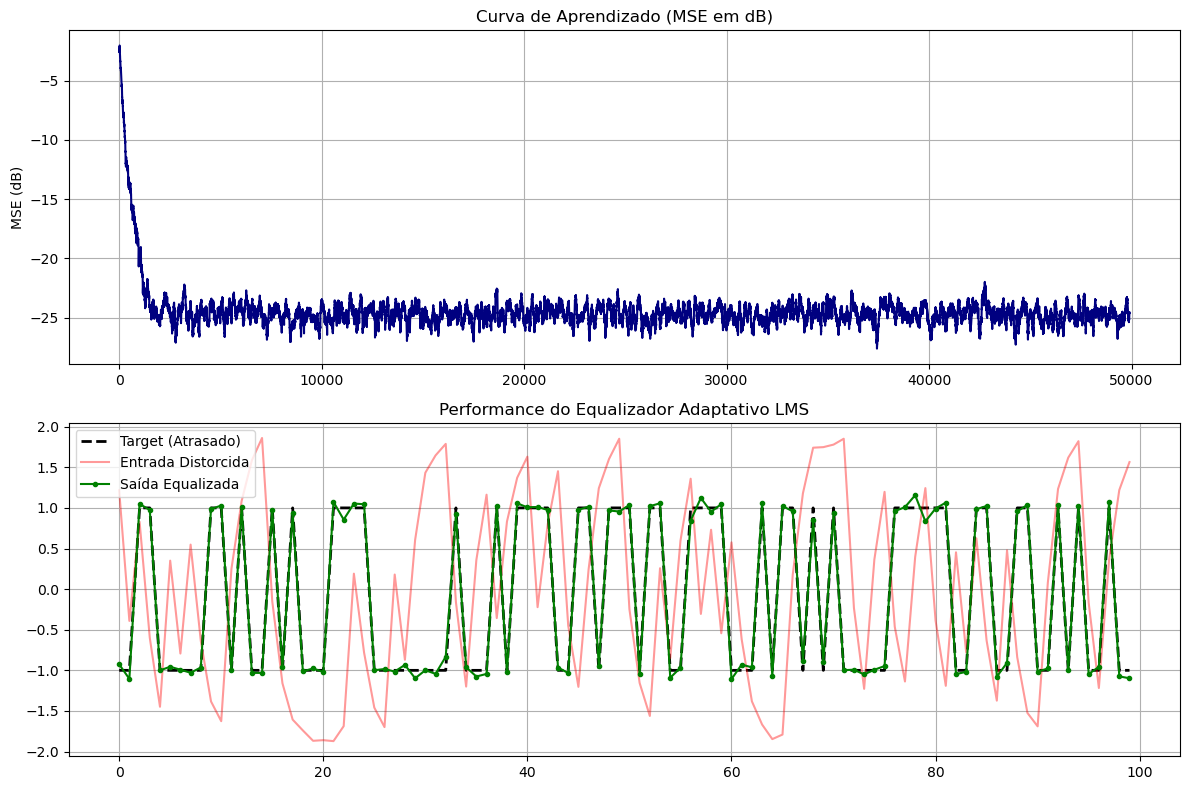

Canal Original: [1.  0.5 0.2 0.1]
Pesos do Equalizador (Primeiros 5): [ 0.002  0.001  0.002 -0.003  0.002]


In [5]:
# Paramêtros
N_samples = 50000
Ntaps = 20      
mu = 0.005      
atraso = Ntaps // 2  # Delay para permitir causalidade 
 # Atraso para centralizar o equalizador

# A. Sinal
d_original = np.sign(np.random.randn(N_samples))

# B. Canal (Usando lfilter para simular sistema causal t=0)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)

# C. Ruído
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# D. Sincronização (Delay)
# O equalizador tentará recuperar d[k - atraso]
d_treino = np.zeros(N_samples)
# O sinal desejado é o original atrasado
d_treino[atraso:] = d_original[:-atraso]

# Execução
out, h_final, erro_quad, historico_h = lms(x, d_treino, Ntaps, mu)

# Visualização 
plt.figure(figsize=(12, 8))

# Gráfico 1: MSE
plt.subplot(2, 1, 1)
# Plotando em dB para ver melhor a queda
mse_db = 10 * np.log10(np.convolve(erro_quad, np.ones(100)/100, mode='valid') + 1e-12)
plt.plot(mse_db, color='navy')
plt.title('Curva de Aprendizado (MSE em dB)')
plt.ylabel('MSE (dB)')
plt.grid(True)

# Gráfico 2: Comparação Visual
zoom_start = 49000
zoom_end = 49100

plt.subplot(2, 1, 2)
# Sinal Desejado d[k - atraso]
plt.plot(d_treino[zoom_start:zoom_end], 'k--', linewidth=2, label='Target (Atrasado)')
# Sinal Distorcido x[k]
plt.plot(x[zoom_start:zoom_end], 'r-', alpha=0.4, label='Entrada Distorcida')
# Saída do Equalizador y[k]
plt.plot(out[zoom_start:zoom_end], 'g.-', linewidth=1.5, label='Saída Equalizada')

plt.title('Performance do Equalizador Adaptativo LMS')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Verificação dos coeficientes
print("Canal Original:", canal)
print("Pesos do Equalizador (Primeiros 5):", np.round(h_final[:5], 3))


 * Solução Ótima de Wiener, necessária para uso de comparação das aplicações do LMS como Equalizador de Canais

$$\mathbf{h}_{opt} = \mathbf{R}_{xx}^{-1} \mathbf{p}_{xd} \rightarrow \text{solução de Wiener que minimiza o MSE}$$

In [6]:
def solve_wiener(x_in, d_ref, N_filtro):
    # Autocorrelação de x (Rxx)
    r_xx = np.correlate(x_in, x_in, mode='full')
    center = len(r_xx) // 2
    r_xx_vec = r_xx[center : center + N_filtro] / len(x_in)
    R_xx = toeplitz(r_xx_vec)
    
    # Correlação cruzada entre d e x (pdx)
    p_dx = np.zeros(N_filtro)
    for k in range(N_filtro):
        # Precisamos alinhar x[n-k] com d[n]
        val = np.mean(d_ref[k:] * x_in[:len(x_in)-k])
        p_dx[k] = val
        
    # Resolve w = inv(R)*p
    return np.linalg.solve(R_xx, p_dx)

In [12]:
# Parâmetros
N_samples = 50000
Ntaps = 20      
mu = 0.002      
atraso = Ntaps // 2  # Delay para permitir causalidade     

# Geração do sinal
d_original = np.sign(np.random.randn(N_samples))
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# Cria o sinal desejado com atraso (Sincronismo)
d_treino = np.zeros(N_samples)
d_treino[atraso:] = d_original[:-atraso]


y_lms, h_lms, erro, historico = lms(x, d_treino, Ntaps, mu)

w_wiener = solve_wiener(x, d_treino, Ntaps)

'''''
#TABELA COMPARATIVA (PRINT DA MATRIZ)


print(f"{'TAP':^5} | {'LMS (Seu Código)':^18} | {'WIENER (Teórico)':^18} | {'DIFERENÇA':^12}")
print("-" * 60)

erro_total = 0
for k in range(Ntaps):
    val_lms = h_lms[k]
    val_wiener = w_wiener[k]
    diff = abs(val_lms - val_wiener)
    erro_total += diff
    
    # Formatação bonita dos números
    print(f"{k:02d}    | {val_lms: .6f}           | {val_wiener: .6f}           | {diff:.6f}")

print("-" * 60)
print(f"Erro Médio Absoluto (MAE): {erro_total/Ntaps:.8f}")

# Validação Rápida
if erro_total/Ntaps < 0.05:
    print("\n LMS convergiu para a solução ótima!")
else:
    print("\n LMS ainda está longe do ótimo. Tente ajustar mu.")
'''

'\'\'\n#TABELA COMPARATIVA (PRINT DA MATRIZ)\n\n\nprint(f"{\'TAP\':^5} | {\'LMS (Seu Código)\':^18} | {\'WIENER (Teórico)\':^18} | {\'DIFERENÇA\':^12}")\nprint("-" * 60)\n\nerro_total = 0\nfor k in range(Ntaps):\n    val_lms = h_lms[k]\n    val_wiener = w_wiener[k]\n    diff = abs(val_lms - val_wiener)\n    erro_total += diff\n    \n    # Formatação bonita dos números\n    print(f"{k:02d}    | {val_lms: .6f}           | {val_wiener: .6f}           | {diff:.6f}")\n\nprint("-" * 60)\nprint(f"Erro Médio Absoluto (MAE): {erro_total/Ntaps:.8f}")\n\n# Validação Rápida\nif erro_total/Ntaps < 0.05:\n    print("\n LMS convergiu para a solução ótima!")\nelse:\n    print("\n LMS ainda está longe do ótimo. Tente ajustar mu.")\n'

In [13]:
# --- 1. Preparação dos Dados ---
data = {
    'Tap (k)': range(len(h_lms)),
    'LMS ': h_lms,
    'Wiener (Teórico)': w_wiener,
    'Diferença Absoluta': np.abs(h_lms - w_wiener)
}

df_comparacao = pd.DataFrame(data)

# --- 2. Veredito Inteligente (Erro Relativo) ---

# Calculamos a "Energia" (Magnitude L1) dos pesos ideais
energia_wiener = np.sum(np.abs(w_wiener))
# Calculamos o erro total acumulado
erro_total = np.sum(df_comparacao['Diferença Absoluta'])

# Erro Relativo Percentual (O "NPD" - Normalized weight Deviation)
erro_relativo_perc = (erro_total / energia_wiener) * 100

# Definindo limiares de rigor
if erro_relativo_perc < 1.0:
    status = " CONVERGÊNCIA EXCELENTE (< 1%)"
    cor_status = "green"
elif erro_relativo_perc < 5.0:
    status = " CONVERGÊNCIA ACEITÁVEL (< 5%)"
    cor_status = "orange"
else:
    status = " DIVERGIU / RUIM (> 5%)"
    cor_status = "red"

print(f"STATUS: {status}")
print(f"Erro Relativo Global: {erro_relativo_perc:.4f}%")
print(f"Erro Médio Absoluto (MAE): {df_comparacao['Diferença Absoluta'].mean():.6f}")

# --- 3. Tabela Estilizada ---

tabela_ajustada = (df_comparacao.style
    .format({
        'Tap (k)': '{:.0f}',
        'LMS (Seu Código)': '{:.6f}',
        'Wiener (Teórico)': '{:.6f}',
        'Diferença Absoluta': '{:.6f}'
    })
    .hide(axis='index')
    
    # Heatmap agora é mais sensível (ajustado para 0.005)
    # Qualquer erro acima de 0.005 já vai ficar bem vermelho
    .background_gradient(subset=['Diferença Absoluta'], cmap='RdYlGn_r', vmin=0, vmax=0.005)
    
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2F5496'),
            ('color', 'white'),
            ('font-family', 'Arial'),
            ('text-align', 'center')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('font-family', 'Arial'),
            ('border-bottom', '1px solid #eee')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('color', cor_status), # A cor do título muda com o status!
            ('padding', '10px')
        ]}
    ])
    .set_caption(f"Status Final: {status} (Erro: {erro_relativo_perc:.2f}%)")
)

try:
    display(tabela_ajustada)
except NameError:
    print(df_comparacao)

STATUS:  CONVERGÊNCIA ACEITÁVEL (< 5%)
Erro Relativo Global: 2.0873%
Erro Médio Absoluto (MAE): 0.001732


Tap (k),LMS,Wiener (Teórico),Diferença Absoluta
0,-0.001895,0.000189,0.002084
1,0.001758,-0.000303,0.002061
2,-0.001935,0.000075,0.002011
3,0.000916,0.000018,0.000898
4,-0.001707,-0.000165,0.001542
5,-0.002063,0.000221,0.002284
6,0.002620,-0.000436,0.003055
7,-0.000464,0.000473,0.000937
8,-0.003967,-0.000486,0.003481
9,0.004936,0.001199,0.003738


## Tabela de Trade-offs: Parâmetros do LMS

A escolha dos parâmetros do algoritmo LMS envolve um compromisso constante entre velocidade de convergência, precisão final (erro residual) e estabilidade.

| Parâmetro | Símbolo | Valor Alto (High) | Valor Baixo (Low) | Impacto Principal |
| :--- | :---: | :--- | :--- | :--- |
| **Passo de Adaptação** | $\mu$ (mu) | **Vantagem:** Convergência rápida (aprende depressa).<br>**Risco:** Erro residual alto (misadjustment), oscilação e possível instabilidade/divergência. | **Vantagem:** Alta precisão no estado estacionário (erro residual mínimo) e estabilidade robusta.<br>**Risco:** Convergência lenta (pode não acompanhar variações rápidas do sistema). | Controla o equilíbrio entre **Velocidade vs. Precisão**. |
| **Ordem do Filtro** | $N_{taps}$ | **Vantagem:** Melhor resolução espectral; capaz de modelar sistemas com respostas ao impulso longas (ecos distantes).<br>**Risco:** Maior custo computacional; convergência mais lenta; maior "ruído de gradiente". | **Vantagem:** Rápido processamento; menor variância na estimativa.<br>**Risco:** *Underfitting* (não consegue modelar a complexidade do sistema); performance pobre se o canal tiver memória longa. | Define a **Capacidade de Modelagem vs. Custo Computacional**. |
| **Número de Amostras** | $N$ | **Vantagem:** Garante que o filtro atinja o regime permanente (steady-state), mesmo com $\mu$ pequeno.<br>**Risco:** Maior tempo de processamento/simulação; latência na resposta. | **Vantagem:** Simulação rápida.<br>**Risco:** O filtro pode ser interrompido ainda na fase transiente (aprendizado incompleto). | Define a **Suficiência Estatística** para a convergência. |

## Convergencia do LMS para Diferentes Valores de Passo de Adaptação

Piso de Ruído Teórico (MMSE): -21.69 dB


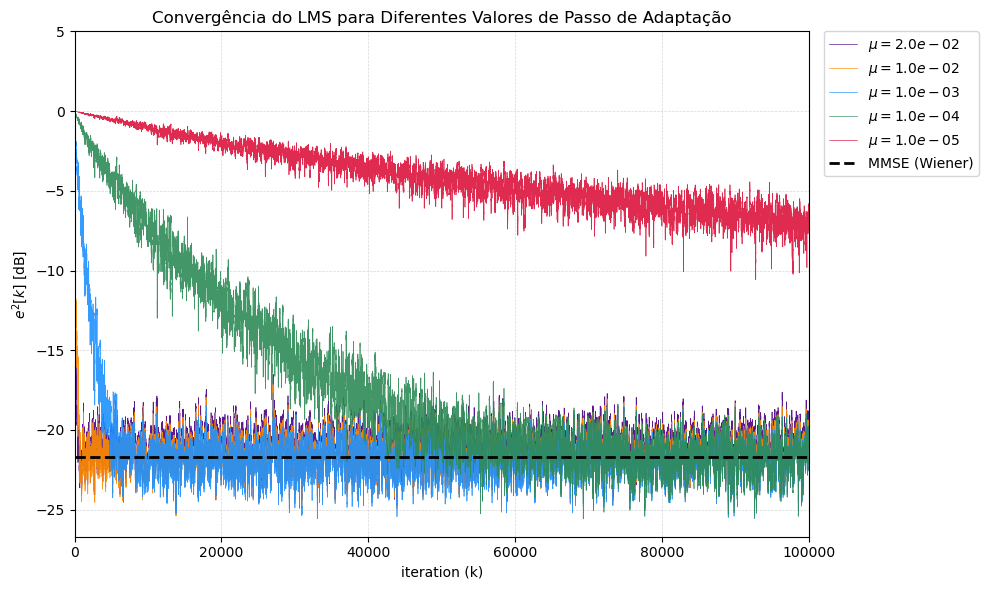

In [9]:
# Parametros 
N_samples = 100000      # 100k para visual denso
Ntaps = 10              
delay = Ntaps // 2               
noise_power = 0.005     

# Geração de Sinais
np.random.seed(42)
d_original = np.sign(np.random.randn(N_samples))

# Canal Simples (O array explícito)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_clean = np.convolve(d_original, canal, mode='full')[:N_samples]

# Ruído
noise = np.random.normal(0, np.sqrt(noise_power), N_samples)
x = x_clean + noise

# Target (Desired) com atraso
d_train = np.zeros(N_samples)
d_train[delay:] = d_original[:-delay]

# Solução de Wiener
w_opt = solve_wiener(x, d_train, Ntaps)

# Calcula o erro residual ótimo (Piso)
y_opt = np.convolve(x, w_opt, mode='full')[:N_samples]
e_opt = d_train - y_opt
mmse_linear = np.mean(e_opt[Ntaps:]**2)
mmse_db = 10 * np.log10(mmse_linear)

print(f"Piso de Ruído Teórico (MMSE): {mmse_db:.2f} dB")


# Definição dos diferentes valores dos passos de adaptação
mu_values = [2e-2, 1e-2, 1e-3, 1e-4, 1e-5]
colors = ['indigo', 'darkorange', 'dodgerblue', 'seagreen', 'crimson']

window_len = 50 # Janela 

plt.figure(figsize=(10, 6))

# Loop usando enumerate
for i, mu in enumerate(mu_values):
    
    # Executa sua função LMS
    _, _, squared_error, _ = lms(x, d_train, Ntaps, mu)
    
    # Processamento visual
    valid_error = squared_error[Ntaps:]
    mse_smooth = np.convolve(valid_error, np.ones(window_len)/window_len, mode='valid')
    error_db = 10 * np.log10(mse_smooth + 1e-20)
    
    plt.plot(error_db, color=colors[i], linewidth=0.5, alpha=0.9, label=f'$\mu = {mu:.1e}$')

# Linha da solução ótima (MMSE)
plt.axhline(y=mmse_db, color='black', linestyle='--', linewidth=2, label='MMSE (Wiener)')

plt.title('Convergência do LMS para Diferentes Valores de Passo de Adaptação')
plt.xlabel('iteration (k)')
plt.ylabel('$e^2[k]$ [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(0, N_samples)
plt.ylim(mmse_db - 5, 5) 

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

 ### Variação do SNR para o LMS
* A solução de Wiener é o ponto ótimo onde a derivada da soma desses dois erros é zero. Ao alterar o SNR, você altera a curva de erro de ruído, deslocando esse ponto ótimo.

SNR (dB)   | MSE Final LMS (dB)   | Wiener Teórico (dB)  | Diferença (dB) 
---------------------------------------------------------------------------
10         | -8.2703              | -8.7240              | 0.4537         
20         | -17.3710             | -17.8298             | 0.4589         
30         | -26.0637             | -26.4881             | 0.4245         


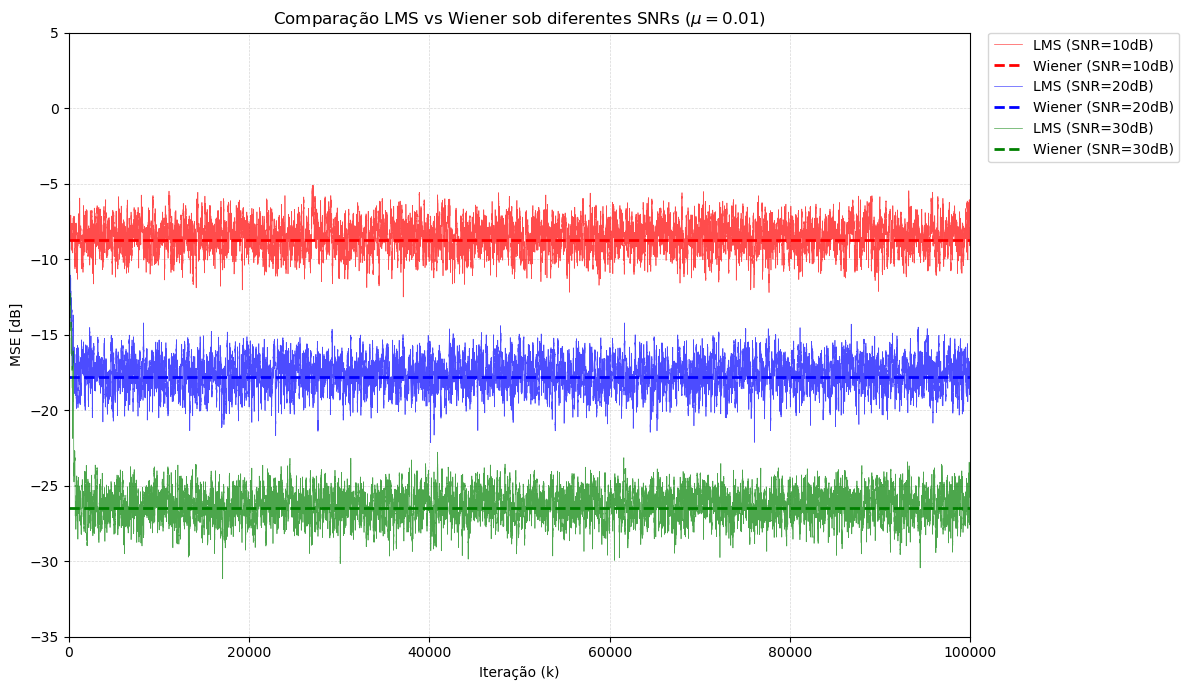

In [10]:
# Parametros
N_samples = 100000      
Ntaps = 10              
delay = Ntaps //2                
mu_fixo = 0.01          # Passo fixo

# Geração de Sinais Aleatorios 
np.random.seed(42)
d_original = np.sign(np.random.randn(N_samples))
d_train = np.zeros(N_samples)
d_train[delay:] = d_original[:-delay]

# Canal
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_clean = np.convolve(d_original, canal, mode='full')[:N_samples]
signal_power = np.var(x_clean)

# Vários valores de SNR
snr_values = [10, 20, 30] 
colors = ['red', 'blue', 'green'] 
window_len = 50 

plt.figure(figsize=(12, 7))

print(f"{'SNR (dB)':<10} | {'MSE Final LMS (dB)':<20} | {'Wiener Teórico (dB)':<20} | {'Diferença (dB)':<15}")
print("-" * 75)

for i, snr_db in enumerate(snr_values):
    
    # Configurar Ruído
    noise_variance = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_variance), N_samples)
    x = x_clean + noise
    
    # Rodar LMS
    _, _, squared_error, _ = lms(x, d_train, Ntaps, mu_fixo)
    
    # Rodar Wiener (Para saber o limite deste cenário específico)
    w_opt = solve_wiener(x, d_train, Ntaps)
    # Calcular o erro residual do Wiener
    y_opt = np.convolve(x, w_opt, mode='full')[:N_samples]
    e_opt = d_train - y_opt
    mmse_linear = np.mean(e_opt[Ntaps:]**2)
    mmse_db = 10 * np.log10(mmse_linear)
    
    # Calcular erro final do LMS (média das últimas 10k amostras)
    lms_final_mse = np.mean(squared_error[-10000:])
    lms_final_db = 10 * np.log10(lms_final_mse)
    
    print(f"{snr_db:<10} | {lms_final_db:<20.4f} | {mmse_db:<20.4f} | {abs(lms_final_db - mmse_db):<15.4f}")

    # Plotagem
    color = colors[i]
    
    # Curva LMS
    valid_error = squared_error[Ntaps:]
    mse_smooth = np.convolve(valid_error, np.ones(window_len)/window_len, mode='valid')
    error_db = 10 * np.log10(mse_smooth + 1e-20)
    
    # Plotamos com label explícito
    plt.plot(error_db, color=color, linewidth=0.5, alpha=0.7, label=f'LMS (SNR={snr_db}dB)')
    
    # Linha Wiener (Tracejada e mais escura)
    plt.axhline(y=mmse_db, color=color, linestyle='--', linewidth=2, label=f'Wiener (SNR={snr_db}dB)')

plt.title(f'Comparação LMS vs Wiener sob diferentes SNRs ($\mu={mu_fixo}$)')
plt.xlabel('Iteração (k)')
plt.ylabel('MSE [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(0, N_samples)
plt.ylim(-35, 5) 

# Legenda posicionada fora
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### LMS x Wiener

 Definindo $M$ como a ordem do filtro (taps) e N como o número de amostras:
 1. LMS (Iterativo)

 * Complexidade: $O(N \cdot M)$.
 * Custo por Amostra: Linear $O(M)$. Realiza apenas somas e multiplicações vetoriais simples a cada iteração.
 * Comportamento: O tempo de processamento cresce linearmente com o tamanho do filtro. É altamente eficiente para filtros longos e hardware limitado.

 2. Solução de Wiener (Matricial)
 * Complexidade: $O(N \cdot M) + O(M^3)$.
 * Gargalo: A inversão da matriz de autocorrelação ($\mathbf{R}_{xx}^{-1}$) domina o custo com complexidade cúbica $O(M^3)$.
 * Comportamento: O tempo de processamento cresce exponencialmente com o tamanho do filtro. Torna-se proibitivo computacionalmente para filtros grandes ($M > 500$).

### Resumo

| Algoritmo | Complexidade Dominante | Escalabilidade () |
| --- | --- | --- |
| **LMS** | Linear  | Excelente |
| **Wiener** | Cúbica  | Ruim | 

Realizando compilação JIT (Warmup)... aguarde.
Compilação concluída! Iniciando Benchmark...

  Ntaps    |   LMS (s)    |  Wiener (s)  | Fator (W/L) 
-------------------------------------------------------
   100     |   0.02018    |   1.40272    |     69.5    x
   500     |   0.07715    |   1.41147    |     18.3    x
   1000    |   0.15155    |   1.41614    |     9.3     x


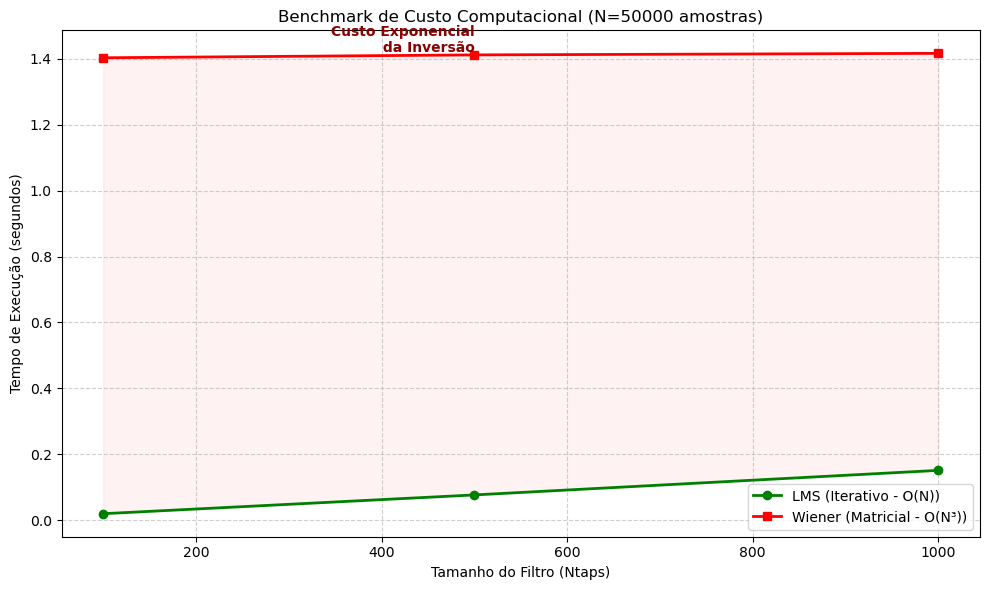

In [11]:
N_samples = 50000       # Tamanho fixo do sinal
mu = 0.001              # Passo fixo
taps_range = [100, 500, 1000] # Tamanhos de filtro crescentes

times_lms = []
times_wiener = []

# --- WARMUP DO NUMBA  ---
print("Realizando compilação JIT (Warmup)... aguarde.")
dummy_data = np.random.randn(2000)
lms(dummy_data, dummy_data, 10, 0.01) # Roda uma vez para compilar
print("Compilação concluída! Iniciando Benchmark...\n")


# 3. LOOP DE MEDIÇÃO


print(f"{'Ntaps':^10} | {'LMS (s)':^12} | {'Wiener (s)':^12} | {'Fator (W/L)':^12}")
print("-" * 55)

for ntaps in taps_range:
    # Geramos dados aleatórios novos a cada rodada para evitar cache
    d = np.sign(np.random.randn(N_samples))
    canal = np.array([1.0, 0.5, 0.2])
    x = np.convolve(d, canal, mode='full')[:N_samples] + np.random.normal(0, 0.01, N_samples)
    d_treino = d # Sem delay complexo, foco é processamento puro
    
    # --- MEDIR LMS ---
    start = time.perf_counter()
    # Chama sua função
    lms(x, d_treino, ntaps, mu)
    end = time.perf_counter()
    t_lms = end - start
    times_lms.append(t_lms)
    
    # --- MEDIR WIENER ---
    start = time.perf_counter()
    try:
        solve_wiener(x, d_treino, ntaps)
    except:
        pass # Evita travar se a matriz for singular (raro com ruído)
    end = time.perf_counter()
    t_wiener = end - start
    times_wiener.append(t_wiener)
    
    ratio = t_wiener / t_lms if t_lms > 0 else 0
    print(f"{ntaps:^10} | {t_lms:^12.5f} | {t_wiener:^12.5f} | {ratio:^12.1f}x")


# 4. GRÁFICO DE COMPARAÇÃO
plt.figure(figsize=(10, 6))

plt.plot(taps_range, times_lms, 'o-', color='green', linewidth=2, label='LMS (Iterativo - O(N))')
plt.plot(taps_range, times_wiener, 's-', color='red', linewidth=2, label='Wiener (Matricial - O(N³))')

plt.title(f'Benchmark de Custo Computacional (N={N_samples} amostras)')
plt.xlabel('Tamanho do Filtro (Ntaps)')
plt.ylabel('Tempo de Execução (segundos)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Área de destaque
plt.fill_between(taps_range, times_lms, times_wiener, color='red', alpha=0.05)
plt.text(taps_range[-2], times_wiener[-2], " Custo Exponencial\n da Inversão", 
         color='darkred', ha='right', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()